# MODIS Fire Dataset (India, 2024)

This dataset comes from **NASA FIRMS (Fire Information for Resource Management System)**, which uses the **MODIS satellite instruments (Aqua and Terra)** to detect active fire hotspots across the globe.

###  Dataset Overview
- **Source:** NASA FIRMS (MODIS Collection)
- **Region:** India
- **Year:** 2024
- **Format:** CSV
- **Captured by:** MODIS satellites (Aqua & Terra)

###  What Each Row Represents
Each row in the dataset corresponds to a **fire hotspot detected by satellite**.
It contains information such as:
- **Latitude & Longitude** - location of the fire pixel
- **Brightness** - intensity of the fire
- **Confidence** - reliability of detection (low, nominal, high)
- **Acquisition Date & Time** - when the fire was observed
- **Satellite** - which satellite captured the data (Aqua or Terra)
- **FRP (Fire Radiative Power)** - energy released by the fire
- **Day/Night flag** - whether detection was during day or night

###  Why This Dataset Matters
This dataset is directly relevant to **CERT‑Sat**, since fires are a **threat signal**.
By analyzing this data, we can:
- Detect unusual fire patterns (anomalies).
- Identify regions with high fire risk.
- Train models to automatically flag potential threats.


In [1]:
# Let's understand important points from above.

### 1. Confidence in Fire Detection

- **Confidence** indicates how reliable the satellite detection of a fire hotspot is.
- It is categorized into:
  - **Low** - weak or uncertain detection
  - **Nominal** - medium certainty, reasonably reliable
  - **High** - strong signal, almost certainly a real fire
- This helps to decide whether to trust a detection or filter out possible false alarms.
- In CERT‑Sat, confidence acts like a **trust score** for threat signals.


### 2. Aqua and Terra Satellites

- **Terra** (launched in 1999) and **Aqua** (launched in 2002) are NASA satellites that orbit Earth in a sun‑synchronous path.
- Both carry the **MODIS instrument (Moderate Resolution Imaging Spectroradiometer)**, which scans Earth in multiple wavelengths.

- **Terra** crosses the equator in the morning (10:30 a.m.), while **Aqua** crosses in the afternoon (1:30 p.m.).

- Together, they provide **global coverage every 1–2 days**, capturing data on fires, vegetation, oceans, clouds, and climate.

- In our dataset:
  - Rows marked **Terra** = fire detected during the morning pass.
  - Rows marked **Aqua** = fire detected during the afternoon pass.


### 3. Fire Radiative Power (FRP)

- **FRP** measures the energy released by a fire, based on thermal radiation detected by MODIS.
- **Unit:** Megawatts (MW).
- **Interpretation:**
  - Higher FRP - stronger, more intense fire.
  - Lower FRP - smaller or less severe fire.
- **Importance:**
  - Indicates fire severity and biomass burning.
  - Helps estimate emissions (CO₂, aerosols).
  - Acts as a key **threat signal** in CERT‑Sat analysis.


In [2]:
# Moving further.

## Step 2: Inspecting Dataset Structure and Quality

Before analyzing fire patterns, we need to understand the dataset’s structure and check its quality.
- **Shape:** How many rows and columns are present.
- **Columns:** Names of all variables (like brightness, confidence, FRP).
- **Data types:** Whether values are numbers, text, or dates.
- **Missing values:** Identify if any data is incomplete.
- **Duplicates:** Check if the same fire record appears more than once.
- **Summary statistics:** Get basic measures (mean, min, max) to understand ranges.


In [3]:
import pandas as pd

# Loaded  dataset
df = pd.read_csv("modis_2024_India.csv")

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 74029 entries, 0 to 74028
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   latitude    74029 non-null  float64
 1   longitude   74029 non-null  float64
 2   brightness  74029 non-null  float64
 3   scan        74029 non-null  float64
 4   track       74029 non-null  float64
 5   acq_date    74029 non-null  str    
 6   acq_time    74029 non-null  int64  
 7   satellite   74029 non-null  str    
 8   instrument  74029 non-null  str    
 9   confidence  74029 non-null  int64  
 10  version     74029 non-null  float64
 11  bright_t31  74029 non-null  float64
 12  frp         74029 non-null  float64
 13  daynight    74029 non-null  str    
 14  type        74029 non-null  int64  
dtypes: float64(8), int64(3), str(4)
memory usage: 8.5 MB


###  Dataset Structure

- **Total records (rows):** 74,029
- **Total variables (columns):** 15

### Insights
- Dataset is **complete**: all 74,029 entries have non‑null values.
- Mix of **numeric (float/int)** and **categorical (string)** variables.
- Variables cover **location, timing, intensity, reliability, and classification** — giving a full picture of fire events.
- Memory usage: ~8.5 MB, which is manageable for analysis on a laptop.

In [ ]:
df.columns

###  Column Details

- **latitude, longitude (float)** - location of fire hotspot
- **brightness (float)** - intensity of fire pixel
- **scan, track (float)** - pixel size in scan/track direction
- **acq_date (string)** - date of detection
- **acq_time (int)** - time of detection (UTC, HHMM format)
- **satellite (string)** - Aqua or Terra
- **instrument (string)** - MODIS instrument
- **confidence (int)** - reliability of detection (low/nominal/high, stored as numbers)
- **version (float)** - dataset processing version
- **bright_t31 (float)** - brightness temperature at 31 microns
- **frp (float)** - Fire Radiative Power (MW)
- **daynight (string)** - detection during day or night
- **type (int)** - fire type classification

In [ ]:
df.head()

###  Why This Matters

Looking at the first few rows helps to confirm following:
- The dataset is loading correctly.
- The values make sense (dates, times, satellite names).
- We can already see variation in fire intensity and confidence levels.

In [ ]:
df.describe()

### Summary Statistics

The dataset provides basic measures for numeric columns:

- **Latitude & Longitude**
  - Range: Latitude ~8.16° to 34.65°, Longitude ~68.53° to 97.07°
  - Insight: Covers the geographic extent of India, confirming dataset region.

- **Brightness**
  - Mean: ~322
  - Min: 300, Max: 509.6
  - Insight: Most fires are moderate intensity, but some extreme hotspots exist.

- **Scan & Track (pixel size)**
  - Typical values: 1.0–1.5
  - Max scan: 4.8, Max track: 2.0
  - Insight: Pixel resolution varies slightly, affecting fire area estimates.

- **Acquisition Time (UTC)**
  - Range: 303 to 2212 (HHMM format)
  - Insight: Fires detected across different times of day.

- **Confidence**
  - Mean: ~63.7
  - Range: 0 to 100
  - Insight: Most detections are medium to high confidence, but some low‑certainty records exist.

- **Version**
  - Constant: 61.03
  - Insight: All records processed with the same dataset version.

- **Brightness T31**
  - Mean: ~302, Range: 267.4 to 400.1
  - Insight: Indicates thermal variation in fire pixels.

- **FRP (Fire Radiative Power)**
  - Mean: ~24.8 MW
  - Range: 0 to 7528.5 MW
  - Insight: Most fires are small (FRP < 25), but rare extreme events release massive energy.

- **Type**
  - Mean: ~0.14, Range: 0 to 3
  - Insight: Majority of records are type 0 (default classification), with few higher codes.


In [ ]:
g print('Missing Values:\n')
 df.isnull().sum()


### Missing Values

- Result: **No missing values** in any of the 15 columns.
- Every record has complete information for location, brightness, confidence, FRP, and other variables.

### Insights
- The dataset is **clean and reliable** — we don’t need to perform imputation (filling gaps) or drop incomplete rows.
- This makes analysis easier and ensures that all fire detections are fully described.
- Having complete data increases confidence in the results of our EDA and later modeling.


In [ ]:
print("Duplicate rows:\n", df.duplicated().sum())


###  Duplicate Records

- Result: **0 duplicate rows** found in the dataset.
- Every fire detection record is unique — no repeated entries.

###  Insights
- This confirms the dataset is **clean and reliable**.
- We don’t need to remove any duplicates, so analysis will not be biased by repeated fire detections.
- Each of the 74,029 records represents a distinct fire hotspot observed by MODIS.


########################################################





In [ ]:
df.head()

In [ ]:
df.info()

In [ ]:
# Convert to datetime (date only)
df['acq_date'] = pd.to_datetime(df['acq_date'], format='%Y-%m-%d')



In [ ]:
df.drop(columns=['year', 'month', 'day'], inplace=True)


In [ ]:
# Pad with zeros
df['acq_time_str'] = df['acq_time'].astype(str).str.zfill(4)




In [ ]:
# Convert integer time directly into datetime.time (24-hour format)
df['acq_time_24'] = pd.to_datetime(df['acq_time'], format='%H%M').dt.time


In [ ]:
# Convert acq_time into datetime64 (24-hour format)
df['acq_time'] = pd.to_datetime(df['acq_time'], format='%H%M')


In [ ]:
df.drop(columns=['acq_time_24'], inplace=True)

In [ ]:
df.drop(columns=['acq_time_str'], inplace=True)

In [ ]:
df['acq_time'].value_counts()

In [ ]:
df['acq_time'] = df['acq_time'].dt.time

In [ ]:
df['acq_time'].head()

In [ ]:
df[['acq_date','acq_time']].head()

### Date & Time Cleaning
- `acq_date` is now in proper **YYYY‑MM‑DD** format.
- `acq_time` is now in clean **24‑hour HH:MM:SS** format without the artificial `1900‑01‑01` date.
- Example rows:
  - `2024-01-01` | `03:46:00`
  - `2024-01-01` | `05:22:00`
- **Outcome:** The dataset now has clear, separate date and time columns that are both human‑friendly and ready for analysis.


In [ ]:
df.head()

In [ ]:
df.columns

### categorizing confidence levels

In [ ]:
def confidence_category(value):
    if value <= 30:
        return "low"
    elif value <= 70:
        return "medium"
    else:
        return "high"

# Create a new column for categories
df['confidence_level'] = df['confidence'].apply(confidence_category)


In [ ]:
df[['confidence','confidence_level' ]]

###  Confidence Cleaning Result
- Original numeric values in `confidence` (0–100) are **preserved**.
- Added a new column `confidence_level` with categories: **low, medium, high**.
- Example transformation:
  - `12 → low`
  - `55 → medium`
  - `88 → high`
- **Work Done:** Created a categorical column alongside the numeric one to make confidence values more relatable and easier to interpret in analysis or visualization.


### Leveling daynight column


In [ ]:
df.head()

- ### Cleaning daynight column

In [15]:
df['daynight'].value_counts()

daynight
D    63336
N    10693
Name: count, dtype: int64

In [16]:
# Map D/N to numeric values
df['daynight_numeric'] = df['daynight'].map({'D': 1, 'N': 0})


In [17]:
df[['daynight', 'daynight_numeric']].value_counts()

daynight  daynight_numeric
D         1                   63336
N         0                   10693
Name: count, dtype: int64

### Day/Night Cleaning Result
- Original `daynight` values (`D`, `N`) are **preserved**.
- Added a new column `daynight_numeric` with numeric encoding:
  - `D → 1` (day)
  - `N → 0` (night)
- **Work Done:** Converted categorical codes into numeric values for easier use in model training while keeping the original column for reference.


- ###  Labeling type column

In [ ]:
df['type'].value_counts()

In [ ]:
# mapping for type column based on FIRMS documentation
type_mapping = {
    0: "fire",       # presumed vegetation fire
    1: "volcano",    # active volcano (not present in current dataset)
    2: "land",       # other static land source
    3: "offshore"    # offshore source like oil
}

# Create a new column with descriptive labels
df['type_label'] = df['type'].map(type_mapping)

# Check distribution with labels
print(df['type_label'].value_counts())


### Type Column Cleaning Result
- Original `type` values (0, 2, 3) are **preserved**.
- Added a new column `type_label` with descriptive categories:
  - `0 → fire` (68,847 records)
  - `2 → land` (5,134 records)
  - `3 → offshore` (48 records)
- **Work Done:** Corrected mapping to reflect NASA FIRMS hotspot source definitions.
- Note: `1 → volcano` is part of the schema but not present in our current dataset.


In [4]:
df['satellite'].value_counts()

satellite
Aqua     49535
Terra    24494
Name: count, dtype: int64

In [5]:
df['instrument'].value_counts()

instrument
MODIS    74029
Name: count, dtype: int64

In [6]:
# Drop the 'instrument' column as it has no variability
df = df.drop(columns=['instrument'])


### Instrument Column
- The `instrument` column contained the same value (`MODIS`) across all rows.
- Since it had no variability, it does not contribute to model training.
- **Action:** Dropped the `instrument` column during preprocessing.


In [20]:
df.head()

,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,confidence,version,bright_t31,frp,daynight,type,daynight_numeric
0,23.7690,86.3923,303.8,3.6,1.8,2024-01-01,346,Terra,13,61.03,291.9,27.5,D,2,1
1,34.0996,74.9958,305.7,1.0,1.0,2024-01-01,522,Terra,55,61.03,278.0,10.1,D,0,1
2,31.0805,78.2029,300.8,1.5,1.2,2024-01-01,522,Terra,18,61.03,284.3,11.5,D,0,1
3,34.0908,74.9942,300.5,1.0,1.0,2024-01-01,522,Terra,28,61.03,280.4,6.9,D,0,1
4,23.6291,74.3663,304.3,1.2,1.1,2024-01-01,524,Terra,43,61.03,292.2,5.1,D,0,1


In [21]:

df['version'].value_counts()


version
61.03    74029
Name: count, dtype: int64

In [23]:
df = df.drop(columns=['version'])

### Version Column
- The `version` column contained a constant value (`61.03`) across all rows.
- As it provided no variability or useful information, it was dropped during preprocessing.


In [22]:
df['scan'].value_counts()

scan
1.0    21838
1.1    15670
1.2     8220
1.3     5177
1.4     3808
1.5     2730
1.6     2500
1.7     1794
1.8     1605
1.9     1300
2.0     1168
2.1     1095
2.2      848
2.3      775
2.5      657
2.4      633
2.7      451
2.6      441
2.8      424
2.9      325
3.0      296
3.1      276
3.2      229
3.8      180
3.3      169
3.4      166
3.7      143
3.5      141
3.6      135
3.9      100
4.4       96
4.6       93
4.3       90
4.1       89
4.7       87
4.5       86
4.0       81
4.8       66
4.2       47
Name: count, dtype: int64

In [8]:
df['frp'].value_counts()

frp
7.4      604
6.5      561
8.1      555
8.0      551
6.8      548
        ... 
195.9      1
429.4      1
546.7      1
480.9      1
247.3      1
Name: count, Length: 2391, dtype: int64

In [9]:
df['frp'].dtype

dtype('float64')

In [10]:
df['frp'].describe()

count    74029.000000
mean        24.841774
std         73.853068
min          0.000000
25%          8.000000
50%         12.400000
75%         22.200000
max       7528.500000
Name: frp, dtype: float64

In [18]:
df.columns

Index(['latitude', 'longitude', 'brightness', 'scan', 'track', 'acq_date',
       'acq_time', 'satellite', 'confidence', 'version', 'bright_t31', 'frp',
       'daynight', 'type', 'daynight_numeric'],
      dtype='str')

#######################################******************############################

In [24]:
df.head()

,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,confidence,bright_t31,frp,daynight,type,daynight_numeric
0,23.7690,86.3923,303.8,3.6,1.8,2024-01-01,346,Terra,13,291.9,27.5,D,2,1
1,34.0996,74.9958,305.7,1.0,1.0,2024-01-01,522,Terra,55,278.0,10.1,D,0,1
2,31.0805,78.2029,300.8,1.5,1.2,2024-01-01,522,Terra,18,284.3,11.5,D,0,1
3,34.0908,74.9942,300.5,1.0,1.0,2024-01-01,522,Terra,28,280.4,6.9,D,0,1
4,23.6291,74.3663,304.3,1.2,1.1,2024-01-01,524,Terra,43,292.2,5.1,D,0,1


In [26]:
df['frp'].describe()

count    74029.000000
mean        24.841774
std         73.853068
min          0.000000
25%          8.000000
50%         12.400000
75%         22.200000
max       7528.500000
Name: frp, dtype: float64

In [27]:
# Define FRP categories based on quartiles
bins = [0, 25, 300, df['frp'].max()]
labels = ['Low', 'Medium', 'High']

df['frp_category'] = pd.cut(df['frp'], bins=bins, labels=labels, include_lowest=True)

# Count fires in each category
df['frp_category'].value_counts()

frp_category
Low       58227
Medium    15361
High        441
Name: count, dtype: int64

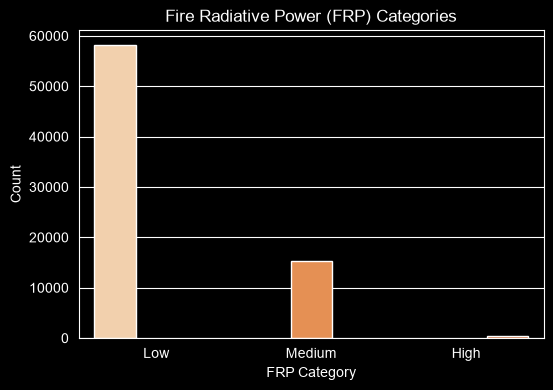

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='frp_category', data=df, hue='frp_category', palette='Oranges', legend=False)

plt.title('Fire Radiative Power (FRP) Categories')
plt.xlabel('FRP Category')
plt.ylabel('Count')
plt.show()



### FRP Category Distribution
- Classified FRP into Low (≤25 MW), Medium (25–300 MW), and High (≥300 MW).
- Plotted a bar chart to visualize category counts.
- Majority of detections fall into the **Low** category, confirming summary statistics and histogram insights.
- Medium intensity fires form a smaller group, while High intensity fires are rare outliers.


In [33]:
df.head()

,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,confidence,bright_t31,frp,daynight,type,daynight_numeric,frp_category
0,23.7690,86.3923,303.8,3.6,1.8,2024-01-01,346,Terra,13,291.9,27.5,D,2,1,Medium
1,34.0996,74.9958,305.7,1.0,1.0,2024-01-01,522,Terra,55,278.0,10.1,D,0,1,Low
2,31.0805,78.2029,300.8,1.5,1.2,2024-01-01,522,Terra,18,284.3,11.5,D,0,1,Low
3,34.0908,74.9942,300.5,1.0,1.0,2024-01-01,522,Terra,28,280.4,6.9,D,0,1,Low
4,23.6291,74.3663,304.3,1.2,1.1,2024-01-01,524,Terra,43,292.2,5.1,D,0,1,Low


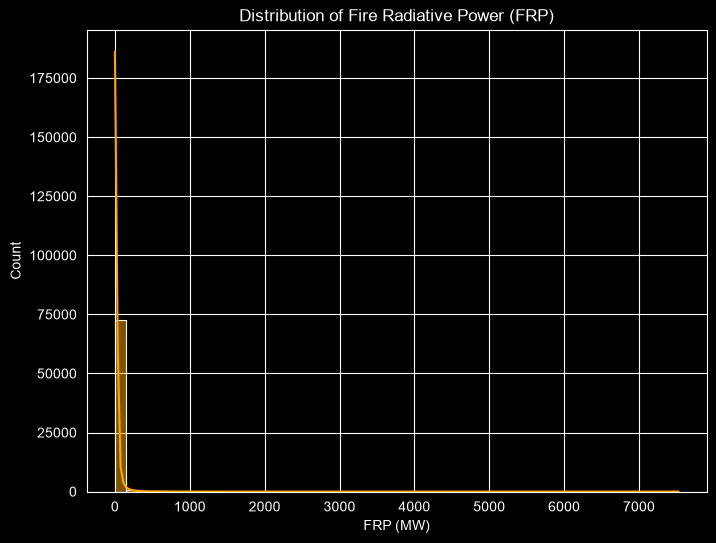

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.histplot(df['frp'], bins=50, kde=True, color='orange')
plt.title('Distribution of Fire Radiative Power (FRP)')
plt.xlabel('FRP (MW)')
plt.ylabel('Count')
plt.show()


### FRP Histogram Insights
- Distribution is right-skewed: majority of fires are low intensity, with a long tail of rare extreme events.
- Peak around ~10–15 MW indicates most common fire intensity.
- Skewness suggests log transformation may be useful for modeling.
- Confirms need for FRP categorization into Low, Medium, High bins.


- ### Bivariate analysis

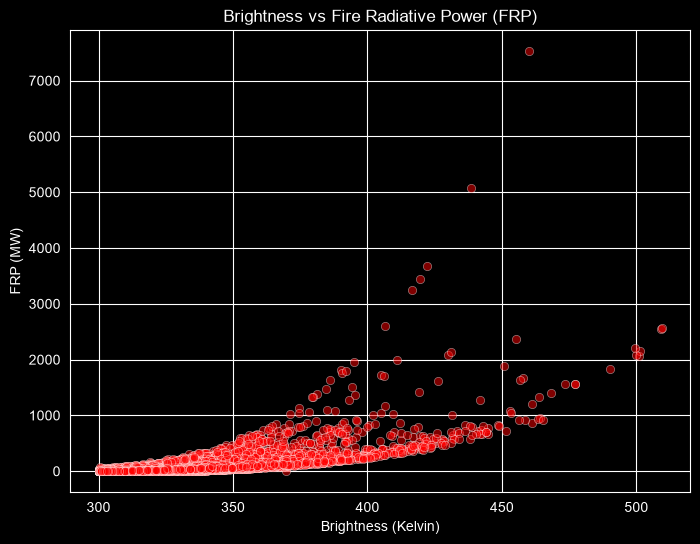

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(x='brightness', y='frp', data=df, alpha=0.5, color='red')

plt.title('Brightness vs Fire Radiative Power (FRP)')
plt.xlabel('Brightness (Kelvin)')
plt.ylabel('FRP (MW)')
plt.show()


### Brightness vs FRP Scatter Plot
- Scatter plot shows a positive correlation: higher brightness values generally correspond to higher FRP.
- Most detections cluster at low FRP, but as brightness increases, FRP values spread wider with some extreme outliers.
- Insight: fire temperature (brightness) is a strong driver of fire intensity (FRP), though other variables also contribute to variability.


In [35]:
# Correlation coefficient
corr = df['brightness'].corr(df['frp'])
print("Correlation between Brightness and FRP:", corr)


Correlation between Brightness and FRP: 0.5208424636597913


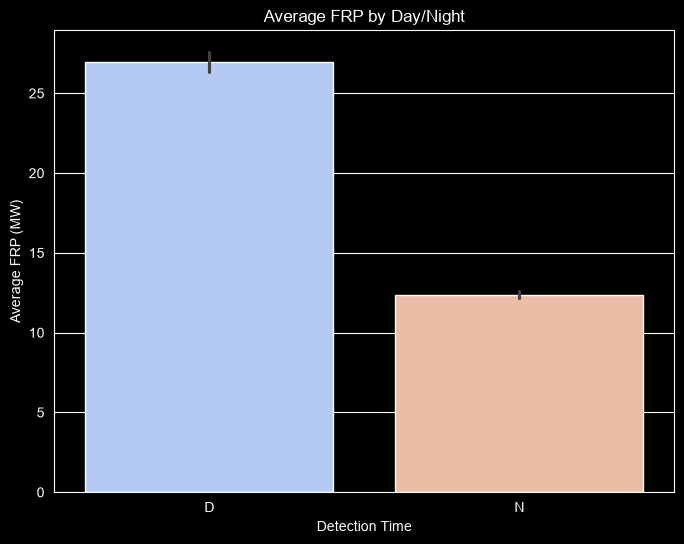

In [39]:
plt.figure(figsize=(8,6))
sns.barplot(x='daynight', y='frp', data=df, estimator='mean', hue='daynight',
            palette='coolwarm', legend=False)

plt.title('Average FRP by Day/Night')
plt.xlabel('Detection Time')
plt.ylabel('Average FRP (MW)')
plt.show()



In [40]:
# Count of detections by Day/Night
counts = df['daynight'].value_counts()
print(counts)

daynight
D    63336
N    10693
Name: count, dtype: int64


### Day/Night vs FRP
- Most detections occur during daytime (confirmed by counts).
- Insight: frequency and intensity together give a fuller picture of day/night fire behavior.


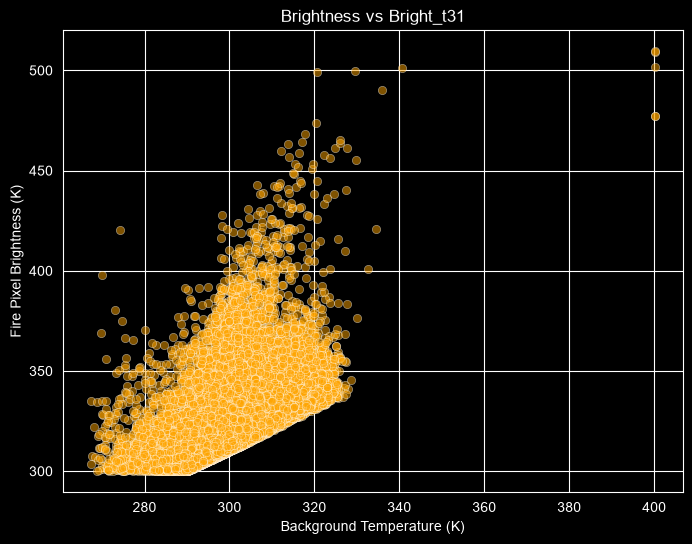

In [41]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='bright_t31', y='brightness', data=df, alpha=0.5, color='orange')

plt.title('Brightness vs Bright_t31')
plt.xlabel('Background Temperature (K)')
plt.ylabel('Fire Pixel Brightness (K)')
plt.show()


### Brightness vs Bright_t31
- Scatter plot shows positive correlation between fire pixel brightness and background temperature.
- Fire pixels are consistently hotter than surroundings.
- Larger difference (Brightness − Bright_t31) indicates stronger fire activity.


In [44]:
corr = df['brightness'].corr(df['bright_t31'])
print("Correlation between Brightness and bright_t31:", corr)

Correlation between Brightness and bright_t31: 0.6311735892569965


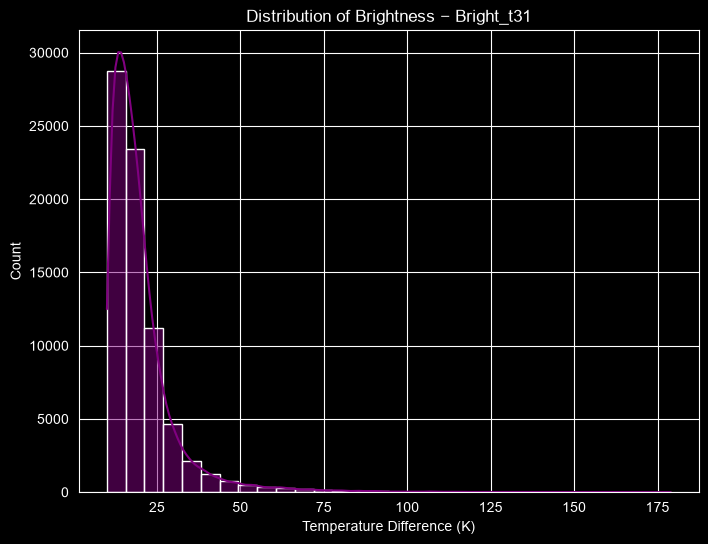

In [45]:
# Create new column for temperature difference
df['temp_diff'] = df['brightness'] - df['bright_t31']

# Plot histogram of temperature difference
plt.figure(figsize=(8,6))
sns.histplot(df['temp_diff'], bins=30, kde=True, color='purple')

plt.title('Distribution of Brightness − Bright_t31')
plt.xlabel('Temperature Difference (K)')
plt.ylabel('Count')
plt.show()


### What temp_diff Highlights
- `temp_diff = brightness − bright_t31` measures how much hotter fire pixels are than background.
- Highlights fire anomaly strength: larger values -> stronger, more intense fires.
- Most detections are moderate, but rare extreme values mark very intense events.


In [47]:
df['temp_diff'].describe()

count    74029.00000
mean        20.10966
std         10.90609
min         10.00000
25%         13.70000
50%         17.40000
75%         22.50000
max        178.90000
Name: temp_diff, dtype: float64

### Brightness − Bright_t31 Distribution
- Right‑skewed histogram: most fires show moderate differences (~13–22 K).
- Median = 17.4 K, Mean = 20.1 K -> mean pulled up by extreme outliers.
- Rare but intense fires (up to 178.9 K difference) create the long right tail.
- Interpretation: majority of fires are moderate, with few extreme events dominating the distribution.


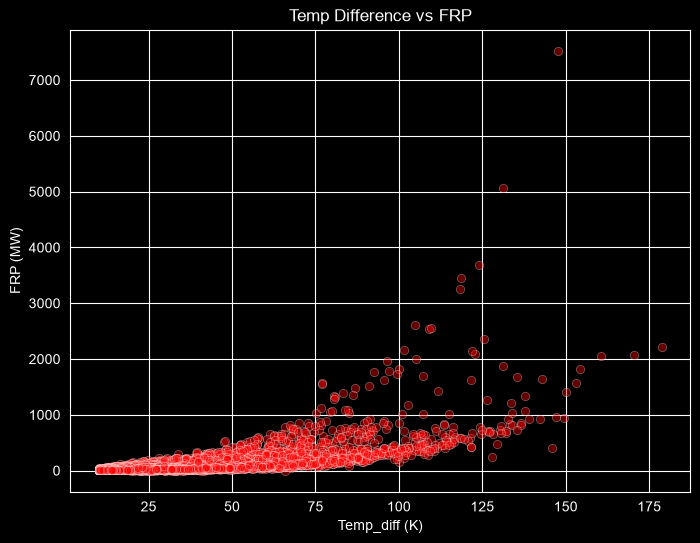

Correlation between Temp Difference and FRP: 0.6148453240441706


In [49]:
# Scatter plot of temp_diff vs FRP
plt.figure(figsize=(8,6))
sns.scatterplot(x='temp_diff', y='frp', data=df, alpha=0.4, color='red')

plt.title('Temp Difference vs FRP')
plt.xlabel('Temp_diff (K)')
plt.ylabel('FRP (MW)')
plt.show()

# Correlation coefficient
corr_temp_frp = df['temp_diff'].corr(df['frp'])
print("Correlation between Temp Difference and FRP:", corr_temp_frp)


### Temp Difference vs FRP
- Larger `temp_diff` -> higher FRP.
- Scatterplot confirms the obvious physical link: hotter fire pixels relative to background release more energy.
- `temp_diff` is a valid indicator of fire intensity.



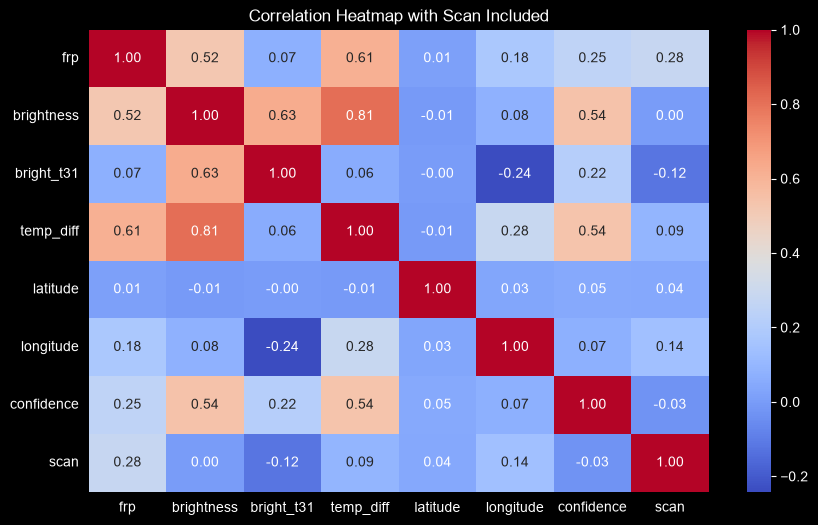

In [51]:
# Include scan if numeric
cols = ['frp', 'brightness', 'bright_t31', 'temp_diff', 'latitude', 'longitude', 'confidence', 'scan']

# Compute correlation matrix
corr = df[cols].corr()

# Plot heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

plt.title('Correlation Heatmap with Scan Included')
plt.show()


### Heatmap Insights (Narration Style)
- FRP <-> Temp_diff(0.61): Strong link -> stronger anomalies mean stronger fires.
- Brightness <-> Temp_diff(0.81): Very strong -> hotter fire pixels drive the anomaly.
- Brightness <-> Bright_t31(0.63): Moderate -> fire pixel temp rises with background temp.
- Confidence <-> Brightness/Temp_diff(0.54): Moderate -> hotter anomalies detected more confidently.
- FRP <-> Brightnes(0.52)s: Moderate -> hotter pixels usually mean stronger FRP.
- Latitude: No clear link -> geography (north/south) doesn’t affect fire strength.
- Longitude: Weak link -> background temp varies slightly east/west.
- Scan: Weak link -> scan line position has little effect, small correlation with FRP.


In [50]:
df.head()

,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,confidence,bright_t31,frp,daynight,type,daynight_numeric,frp_category,temp_diff
0,23.7690,86.3923,303.8,3.6,1.8,2024-01-01,346,Terra,13,291.9,27.5,D,2,1,Medium,11.9
1,34.0996,74.9958,305.7,1.0,1.0,2024-01-01,522,Terra,55,278.0,10.1,D,0,1,Low,27.7
2,31.0805,78.2029,300.8,1.5,1.2,2024-01-01,522,Terra,18,284.3,11.5,D,0,1,Low,16.5
3,34.0908,74.9942,300.5,1.0,1.0,2024-01-01,522,Terra,28,280.4,6.9,D,0,1,Low,20.1
4,23.6291,74.3663,304.3,1.2,1.1,2024-01-01,524,Terra,43,292.2,5.1,D,0,1,Low,12.1


In [53]:
df.to_csv('cleaned_fire_data.csv', index=False)